# AI Driven Export Market Decision Support System

## QM 640 Capstone Project

### Student
Pavithra Bharathi

### Walsh University

---

## Project Objective

This project aims to develop an AI-driven export market decision support system to identify high-potential international markets for Indian exports. The study integrates TradeStat, UN Comtrade, and World Bank datasets to analyze historical trade performance, evaluate macroeconomic indicators, and generate data-driven recommendations for exporters.

---

## Research Questions

RQ1.
Which export commodities and international markets exhibit the highest growth potential for India?

RQ2.
Which macroeconomic indicators significantly influence India's export performance?

RQ3.
How does international competition affect India's export opportunities across selected commodities?

RQ4.
Can machine learning models accurately identify attractive export markets?

---

## Data Sources

1. TradeStat (Government of India)

2. UN Comtrade

3. World Bank World Development Indicators

---

## Expected Outputs

• Clean integrated dataset

• Exploratory Data Analysis

• Statistical Analysis

• Machine Learning Models

• Export Market Recommendation Framework

Environment Setup

In [196]:
# =====================================
# INSTALL REQUIRED PACKAGES
# =====================================

!pip install openpyxl
!pip install xlrd
!pip install seaborn
!pip install statsmodels
!pip install xgboost
!pip install missingno

Clone Repository

In [197]:
# =====================================
# CLONE GITHUB REPOSITORY
# =====================================

!git clone https://github.com/bharathipavithra10-cmd/AI-Export-Market-Decision-Support.git

fatal: destination path 'AI-Export-Market-Decision-Support' already exists and is not an empty directory.


In [198]:
# =====================================
# IMPORT LIBRARIES
# =====================================

import os
import re
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

Project Directory

In [199]:
PROJECT_ROOT = Path("/content/AI-Export-Market-Decision-Support")

RAW_DATA = PROJECT_ROOT/"data"/"raw"

TRADESTAT_DIR = RAW_DATA/"tradestate"

UNCOMTRADE_DIR = RAW_DATA/"un_comtrade"

WORLD_BANK_DIR = RAW_DATA/"WORLD_BANK"

OUTPUT_DIR = PROJECT_ROOT/"outputs"

FIGURES_DIR = OUTPUT_DIR/"figures"

TABLES_DIR = OUTPUT_DIR/"tables"

CLEAN_DIR = PROJECT_ROOT/"data"/"cleaned"

PROCESSED_DIR = PROJECT_ROOT/"data"/"processed"

Create Output Folders

In [200]:
for folder in [

    OUTPUT_DIR,

    FIGURES_DIR,

    TABLES_DIR,

    CLEAN_DIR,

    PROCESSED_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Folders Created Successfully")

Folders Created Successfully


Verify Dataset

In [201]:
print("="*50)
print("TRADESTAT FILES")
print("="*50)

trade_files = sorted(
    TRADESTAT_DIR.rglob("*.xlsx")
)

print(len(trade_files))

for f in trade_files:

    print(f.name)

TRADESTAT FILES
29
TradeStat-Eidb-Export-Commodity-wise-all-countries_2020_2021.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2021_2022.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2022_2023.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2023_2024.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2024_2025.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2025-2026.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2020_2021.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2021_2022.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2022_2023.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2023_2024.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2024_2025.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2025_2026.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2020_2021.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2021_2022.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2022_2

Verify UN Comtrade

In [202]:
print("="*50)
print("UN COMTRADE")
print("="*50)

comtrade_files = sorted(
    UNCOMTRADE_DIR.glob("*.xlsx")
)

for f in comtrade_files:

    print(f.name)

UN COMTRADE
TradeData_7_21_2026_1_4_20.xlsx


Verify World Bank

In [203]:
print("="*50)
print("WORLD BANK")
print("="*50)

wb_files = sorted(
    WORLD_BANK_DIR.glob("*.xlsx")
)

for f in wb_files:

    print(f.name)

WORLD BANK
P_Data_Extract_From_World_Development_Indicators.xlsx


Dataset Summary

In [204]:
summary = pd.DataFrame({

    "Dataset":[

        "TradeStat",

        "UN Comtrade",

        "World Bank"

    ],

    "Files":[

        len(trade_files),

        len(comtrade_files),

        len(wb_files)

    ]

})

summary

,Dataset,Files
0,TradeStat,29
1,UN Comtrade,1
2,World Bank,1


Data Quality Assessment

In [205]:
print("="*60)

print("PROJECT SUMMARY")

print("="*60)

print(f"TradeStat Files : {len(trade_files)}")

print(f"UN Comtrade Files : {len(comtrade_files)}")

print(f"World Bank Files : {len(wb_files)}")

PROJECT SUMMARY
TradeStat Files : 29
UN Comtrade Files : 1
World Bank Files : 1


Notebook Progress

In [206]:
progress = pd.DataFrame({

    "Task":[

        "Repository",

        "Data Loading",

        "Data Cleaning",

        "Data Integration",

        "Feature Engineering",

        "EDA",

        "Regression",

        "Machine Learning"

    ],

    "Status":[

        "Completed",

        "Completed",

        "In Progress",

        "Pending",

        "Pending",

        "Pending",

        "Pending",

        "Pending"

    ]

})

progress

,Task,Status
0,Repository,Completed
1,Data Loading,Completed
2,Data Cleaning,In Progress
3,Data Integration,Pending
4,Feature Engineering,Pending
5,EDA,Pending
6,Regression,Pending
7,Machine Learning,Pending


PART 2 – Data Cleaning & Integration

In [207]:
# ==========================================
# LOAD ALL TRADESTAT FILES
# ==========================================

trade_files = sorted(TRADESTAT_DIR.rglob("*.xlsx"))

print(f"Total files found : {len(trade_files)}")

Total files found : 29


TradeStat Loader

In [208]:
def load_tradestat(file_path):

    df = pd.read_excel(
        file_path,
        skiprows=2
    )

    df.columns = [
        "Serial_No",
        "Country",
        "Export_Previous",
        "Export_Current",
        "Export_Growth",
        "Quantity_Previous",
        "Quantity_Current",
        "Quantity_Growth"
    ]

    df = df.dropna(how="all")

    df = df[
        ~df["Country"]
        .astype(str)
        .str.contains("Total",case=False)
    ]

    commodity = file_path.parent.name.replace(
        "commodity_",""
    )

    year = re.findall(
        r"(20\d{2})[_-](20\d{2})",
        file_path.name
    )[0][1]

    df["Commodity"]=commodity
    df["Year"]=int(year)

    return df

Read Everything

In [209]:
trade_frames=[]

for file in trade_files:

    try:

        trade_frames.append(
            load_tradestat(file)
        )

    except Exception as e:

        print(file)

        print(e)

Combine

In [210]:
from pathlib import Path

PROJECT_ROOT = Path("/content/AI-Export-Market-Decision-Support")

print(PROJECT_ROOT.exists())

True


In [211]:

import os

for root, dirs, files in os.walk("/content/AI-Export-Market-Decision-Support"):
    print(root)

/content/AI-Export-Market-Decision-Support
/content/AI-Export-Market-Decision-Support/notebooks
/content/AI-Export-Market-Decision-Support/outputs
/content/AI-Export-Market-Decision-Support/outputs/figures
/content/AI-Export-Market-Decision-Support/outputs/tables
/content/AI-Export-Market-Decision-Support/figures
/content/AI-Export-Market-Decision-Support/data
/content/AI-Export-Market-Decision-Support/data/processed
/content/AI-Export-Market-Decision-Support/data/sample
/content/AI-Export-Market-Decision-Support/data/cleaned
/content/AI-Export-Market-Decision-Support/data/raw
/content/AI-Export-Market-Decision-Support/data/raw/un_comtrade
/content/AI-Export-Market-Decision-Support/data/raw/WORLD_BANK
/content/AI-Export-Market-Decision-Support/data/raw/tradestate
/content/AI-Export-Market-Decision-Support/data/raw/tradestate/commodity_71
/content/AI-Export-Market-Decision-Support/data/raw/tradestate/commodity_27
/content/AI-Export-Market-Decision-Support/data/raw/tradestate/commodity_3

In [212]:
import os

print(os.listdir("/content/AI-Export-Market-Decision-Support/data/raw"))

['rreadme.md', 'un_comtrade', 'readme.md', 'WORLD_BANK', 'tradestate']


In [213]:
tradestat=pd.concat(
    trade_frames,
    ignore_index=True
)

print(tradestat.shape)

tradestat.head()

(6040, 10)


,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year
0,1,AFGHANISTAN,0.31,0.84,167.87,NaN,NaN,NaN,27,2021
1,2,ALBANIA,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021
2,3,ALGERIA,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021
3,4,ANGOLA,0.24,0.87,270.22,NaN,NaN,NaN,27,2021
4,5,ARGENTINA,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021


Numeric Conversion

In [214]:
numeric_columns=[

"Export_Previous",

"Export_Current",

"Export_Growth",

"Quantity_Previous",

"Quantity_Current",

"Quantity_Growth"

]

for col in numeric_columns:

    tradestat[col]=(

        tradestat[col]

        .astype(str)

        .str.replace(",","")

        .str.strip()

    )

    tradestat[col]=pd.to_numeric(

        tradestat[col],

        errors="coerce"

    )

Missing Values

In [215]:
missing=tradestat.isnull().sum()

missing=missing.reset_index()

missing.columns=[

"Variable",

"Missing Values"

]

missing

,Variable,Missing Values
0,Serial_No,0
1,Country,0
2,Export_Previous,239
3,Export_Current,234
4,Export_Growth,473
5,Quantity_Previous,6040
6,Quantity_Current,6040
7,Quantity_Growth,6040
8,Commodity,0
9,Year,0


Duplicate Rows

In [216]:
duplicates=tradestat.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


Save Clean TradeStat

In [217]:
tradestat.to_csv(

    CLEAN_DIR/"tradestat_clean.csv",

    index=False

)

Load UN Comtrade

In [218]:
# ==========================================
# LOAD UN COMTRADE (XLSX)
# ==========================================

comtrade_file = list(UNCOMTRADE_DIR.glob("*.xlsx"))[0]

print("Loading:", comtrade_file.name)

comtrade = pd.read_excel(
    comtrade_file,
    engine="openpyxl"
)

print(comtrade.shape)

comtrade.head()

Loading: TradeData_7_21_2026_1_4_20.xlsx
(100000, 47)


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,1146.40,640.00,1146.40,0,False,True
1,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,572806.98,555763.48,572806.98,0,False,True
2,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,63.00,20.00,63.00,0,False,True
3,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,886.95,850.01,886.95,0,False,True
4,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,66.03,50.00,66.03,0,False,True


Keep Required Columns

In [219]:
required=[

"refYear",

"partnerDesc",

"partnerISO",

"cmdCode",

"cmdDesc",

"flowDesc",

"primaryValue",

"qty",

"netWgt",

"reporterDesc"

]

comtrade=comtrade[required]

comtrade.head()

,refYear,partnerDesc,partnerISO,cmdCode,cmdDesc,flowDesc,primaryValue,qty,netWgt,reporterDesc
0,2020,Venezuela,VEN,84,"Nuclear reactors, boilers, machinery and mecha...",Import,1146.40,0,0.0,Angola
1,2020,Zambia,ZMB,84,"Nuclear reactors, boilers, machinery and mecha...",Import,572806.98,0,0.0,Angola
2,2020,Saudi Arabia,SAU,71,"Natural, cultured pearls; precious, semi-preci...",Import,63.00,0,0.0,Angola
3,2020,Singapore,SGP,71,"Natural, cultured pearls; precious, semi-preci...",Import,886.95,0,0.0,Angola
4,2020,Mozambique,MOZ,71,"Natural, cultured pearls; precious, semi-preci...",Import,66.03,0,0.0,Angola


Rename Columns

In [220]:
comtrade.columns=[

"Year",

"Country",

"Country_ISO",

"Commodity",

"Commodity_Name",

"Trade_Flow",

"Trade_Value",

"Quantity",

"Net_Weight",

"Reporter"

]

Keep Only India's Imports

In [221]:
comtrade=comtrade[

    (comtrade["Reporter"]=="India")

]

comtrade.head()

,Year,Country,Country_ISO,Commodity,Commodity_Name,Trade_Flow,Trade_Value,Quantity,Net_Weight,Reporter


Convert Numerics

In [222]:
for col in [

"Trade_Value",

"Quantity",

"Net_Weight"

]:

    comtrade[col]=pd.to_numeric(

        comtrade[col],

        errors="coerce"

    )

Save

In [223]:
comtrade.to_csv(

    CLEAN_DIR/"uncomtrade_clean.csv",

    index=False

)

Load World Bank

In [224]:
wb_file=list(

WORLD_BANK_DIR.glob("*.xlsx")

)[0]

worldbank=pd.read_excel(

wb_file,

sheet_name=0

)

worldbank.head()

,Country Name,Country Code,Series Name,Series Code,2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,19955929052.149597,14259995441.075907,14497243872.133739,17152234636.871508,17778508875.739643,..
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,-2.351101,-20.738839,-6.240172,2.266944,1.873193,..
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,510.787063,356.496214,357.261153,413.757895,416.871146,..
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,39068979,40000412,40578842,41454761,42647492,43844111
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.601888,5.133203,13.712102,-4.644709,-6.601186,..


Keep Indicators

In [225]:
worldbank.columns

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code',
       '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]',
       '2024 [YR2024]', '2025 [YR2025]'],
      dtype='object')

World Bank Cleaning, Data Integration & Feature Engineering

In [226]:
# ==========================================
# WORLD BANK OVERVIEW
# ==========================================

print("Shape:", worldbank.shape)

display(worldbank.head())

print("\nColumns:")
print(worldbank.columns.tolist())

Shape: (2125, 10)


,Country Name,Country Code,Series Name,Series Code,2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,19955929052.149597,14259995441.075907,14497243872.133739,17152234636.871508,17778508875.739643,..
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,-2.351101,-20.738839,-6.240172,2.266944,1.873193,..
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,510.787063,356.496214,357.261153,413.757895,416.871146,..
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,39068979,40000412,40578842,41454761,42647492,43844111
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.601888,5.133203,13.712102,-4.644709,-6.601186,..



Columns:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']


In [227]:
# ==========================================
# REMOVE EMPTY ROWS/COLUMNS
# ==========================================

worldbank = worldbank.dropna(how="all")
worldbank = worldbank.dropna(axis=1, how="all")

print(worldbank.shape)

(2122, 10)


In [228]:
# ==========================================
# CLEAN YEAR COLUMN NAMES
# ==========================================

worldbank.columns = (
    worldbank.columns
    .str.replace(r"\s*\[YR\d+\]", "", regex=True)
)

print(worldbank.columns)

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code', '2020',
       '2021', '2022', '2023', '2024', '2025'],
      dtype='object')


In [229]:
# ==========================================
# CONVERT YEARS TO ROWS
# ==========================================

year_columns = ["2020","2021","2022","2023","2024","2025"]

worldbank_long = pd.melt(
    worldbank,
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name",
        "Series Code"
    ],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

worldbank_long["Year"] = worldbank_long["Year"].astype(int)

print(worldbank_long.shape)
display(worldbank_long.head(10))

(12732, 6)


,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,2020,19955929052.149597
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.351101
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2020,510.787063
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2020,39068979
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2020,5.601888
5,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,2020,46.709895
6,Afghanistan,AFG,Imports of goods and services (% of GDP),NE.IMP.GNFS.ZS,2020,36.289077
7,Afghanistan,AFG,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,2020,10.420817
8,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2020,938546103425.609009
9,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.930764


In [230]:
year_columns = ["2020", "2021", "2022", "2023", "2024", "2025"]

worldbank_long = pd.melt(
    worldbank,
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name",
        "Series Code"
    ],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

worldbank_long["Year"] = worldbank_long["Year"].astype(int)

display(worldbank_long.head(10))

,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,2020,19955929052.149597
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.351101
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2020,510.787063
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2020,39068979
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2020,5.601888
5,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,2020,46.709895
6,Afghanistan,AFG,Imports of goods and services (% of GDP),NE.IMP.GNFS.ZS,2020,36.289077
7,Afghanistan,AFG,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,2020,10.420817
8,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2020,938546103425.609009
9,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.930764


In [231]:
worldbank_clean = worldbank_long.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value",
    aggfunc="first"
).reset_index()

worldbank_clean.columns.name = None

display(worldbank_clean.head())

,Country Name,Year,Exports of goods and services (% of GDP),GDP (current US$),GDP growth (annual %),GDP per capita (current US$),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Population, total",Trade (% of GDP)
0,Afghanistan,2020,10.420817,19955929052.149597,-2.351101,510.787063,36.289077,5.601888,39068979,46.709895
1,Afghanistan,2021,14.342153,14259995441.075907,-20.738839,356.496214,37.069564,5.133203,40000412,51.411716
2,Afghanistan,2022,18.380042,14497243872.133739,-6.240172,357.261153,54.505427,13.712102,40578842,72.88547
3,Afghanistan,2023,16.235278,17152234636.871508,2.266944,413.757895,50.7643,-4.644709,41454761,66.999578
4,Afghanistan,2024,15.702752,17778508875.739643,1.873193,416.871146,68.060273,-6.601186,42647492,83.763025


In [232]:
master = tradestat.merge(
    worldbank_clean,
    left_on=["Country", "Year"],
    right_on=["Country Name", "Year"],
    how="left"
)

In [233]:
worldbank_long = worldbank_long.dropna(subset=["Series Name"])

In [234]:
worldbank_clean = worldbank_clean.rename(columns={
    "Country Name": "Country",
    "GDP (current US$)": "GDP",
    "GDP growth (annual %)": "GDP_Growth",
    "GDP per capita (current US$)": "GDP_Per_Capita",
    "Population, total": "Population",
    "Inflation, consumer prices (annual %)": "Inflation",
    "Exports of goods and services (% of GDP)": "Exports_GDP",
    "Imports of goods and services (% of GDP)": "Imports_GDP",
    "Trade (% of GDP)": "Trade_GDP"
})

In [235]:
# ==========================================
# STANDARDIZE COUNTRY NAMES
# ==========================================

def clean_country(df, column):

    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.title()
    )

    return df

tradestat = clean_country(tradestat, "Country")
comtrade = clean_country(comtrade, "Country")
worldbank_clean = clean_country(worldbank_clean, "Country")

In [236]:
print("TradeStat :", tradestat.shape)

print("Comtrade :", comtrade.shape)

print("World Bank :", worldbank_clean.shape)

TradeStat : (6040, 10)
Comtrade : (0, 10)
World Bank : (1590, 10)


In [237]:
print(tradestat.columns.tolist())

['Serial_No', 'Country', 'Export_Previous', 'Export_Current', 'Export_Growth', 'Quantity_Previous', 'Quantity_Current', 'Quantity_Growth', 'Commodity', 'Year']


In [238]:
print(comtrade.columns.tolist())

['Year', 'Country', 'Country_ISO', 'Commodity', 'Commodity_Name', 'Trade_Flow', 'Trade_Value', 'Quantity', 'Net_Weight', 'Reporter']


In [239]:
tradestat.head()

,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year
0,1,Afghanistan,0.31,0.84,167.87,NaN,NaN,NaN,27,2021
1,2,Albania,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021
2,3,Algeria,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021
3,4,Angola,0.24,0.87,270.22,NaN,NaN,NaN,27,2021
4,5,Argentina,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021


In [240]:
# ==========================================
# MERGE TRADESTAT + WORLD BANK
# ==========================================

master = tradestat.merge(
    worldbank_clean,
    on=["Country", "Year"],
    how="left"
)

print(master.shape)
display(master.head())

(6040, 18)


,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year,Exports_GDP,GDP,GDP_Growth,GDP_Per_Capita,Imports_GDP,Inflation,Population,Trade_GDP
0,1,Afghanistan,0.31,0.84,167.87,NaN,NaN,NaN,27,2021,14.342153,14259995441.075907,-20.738839,356.496214,37.069564,5.133203,40000412,51.411716
1,2,Albania,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021,31.133056,18031989573.029366,8.969576,7242.455131,44.457348,2.041472,2489762,75.590404
2,3,Algeria,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021,23.444367,186231205262.082367,3.8,4160.559267,23.392692,7.226063,44761099,46.837059
3,4,Angola,0.24,0.87,270.22,NaN,NaN,NaN,27,2021,40.092305,78283923543.823669,1.090584,2266.968349,22.436465,25.754295,34532429,62.528771
4,5,Argentina,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021,18.066709,486564085480.035522,10.441812,10738.017922,15.01198,48.409379,45312281,33.07869


In [241]:
# ==========================================
# AGGREGATE UN COMTRADE
# ==========================================

comtrade_summary = (
    comtrade
    .groupby(["Country", "Year"], as_index=False)
    .agg({
        "Trade_Value": "sum",
        "Quantity": "sum",
        "Net_Weight": "sum"
    })
)

display(comtrade_summary.head())

,Country,Year,Trade_Value,Quantity,Net_Weight


In [242]:
# ==========================================
# MERGE COMTRADE
# ==========================================

master = master.merge(
    comtrade_summary,
    on=["Country", "Year"],
    how="left"
)

print(master.shape)

(6040, 21)


In [243]:
master = master.rename(columns={
    "Trade_Value": "Import_Value",
    "Quantity": "Import_Quantity",
    "Net_Weight": "Import_Net_Weight"
})

In [244]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

master["Export_Value"] = master["Export_Current"]

master["Export_Growth_Rate"] = (
    (master["Export_Current"] - master["Export_Previous"])
    / master["Export_Previous"]
) * 100

master["Quantity_Growth_Rate"] = (
    (master["Quantity_Current"] - master["Quantity_Previous"])
    / master["Quantity_Previous"]
) * 100

In [245]:
# ==========================================
# MARKET SHARE
# ==========================================

year_totals = (
    master.groupby("Year")["Export_Value"]
    .transform("sum")
)

master["Market_Share"] = (
    master["Export_Value"] / year_totals
) * 100

In [246]:
# ==========================================
# Missing Values
# ==========================================
missing = (
    master.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing)

,0
Quantity_Current,6040
Quantity_Previous,6040
Quantity_Growth,6040
Import_Net_Weight,6040
Quantity_Growth_Rate,6040
Import_Value,6040
Import_Quantity,6040
GDP,2655
Exports_GDP,2655
Trade_GDP,2655


In [247]:
# ==========================================
# Save Master Dataset
# ==========================================
master.to_csv(
    PROCESSED_DIR / "master_dataset.csv",
    index=False
)

print("Master dataset saved successfully.")

Master dataset saved successfully.


In [248]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Serial_No             6040 non-null   object 
 1   Country               6040 non-null   object 
 2   Export_Previous       5801 non-null   float64
 3   Export_Current        5806 non-null   float64
 4   Export_Growth         5567 non-null   float64
 5   Quantity_Previous     0 non-null      float64
 6   Quantity_Current      0 non-null      float64
 7   Quantity_Growth       0 non-null      float64
 8   Commodity             6040 non-null   object 
 9   Year                  6040 non-null   int64  
 10  Exports_GDP           3385 non-null   object 
 11  GDP                   3385 non-null   object 
 12  GDP_Growth            3385 non-null   object 
 13  GDP_Per_Capita        3385 non-null   object 
 14  Imports_GDP           3385 non-null   object 
 15  Inflation            

In [249]:
master.info()
master.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Serial_No             6040 non-null   object 
 1   Country               6040 non-null   object 
 2   Export_Previous       5801 non-null   float64
 3   Export_Current        5806 non-null   float64
 4   Export_Growth         5567 non-null   float64
 5   Quantity_Previous     0 non-null      float64
 6   Quantity_Current      0 non-null      float64
 7   Quantity_Growth       0 non-null      float64
 8   Commodity             6040 non-null   object 
 9   Year                  6040 non-null   int64  
 10  Exports_GDP           3385 non-null   object 
 11  GDP                   3385 non-null   object 
 12  GDP_Growth            3385 non-null   object 
 13  GDP_Per_Capita        3385 non-null   object 
 14  Imports_GDP           3385 non-null   object 
 15  Inflation            

,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year,...,Inflation,Population,Trade_GDP,Import_Value,Import_Quantity,Import_Net_Weight,Export_Value,Export_Growth_Rate,Quantity_Growth_Rate,Market_Share
0,1,Afghanistan,0.31,0.84,167.87,NaN,NaN,NaN,27,2021,...,5.133203,40000412,51.411716,NaN,NaN,NaN,0.84,170.967742,NaN,0.000795
1,2,Albania,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021,...,2.041472,2489762,75.590404,NaN,NaN,NaN,0.00,-100.000000,NaN,0.000000
2,3,Algeria,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021,...,7.226063,44761099,46.837059,NaN,NaN,NaN,2.08,-34.796238,NaN,0.001969
3,4,Angola,0.24,0.87,270.22,NaN,NaN,NaN,27,2021,...,25.754295,34532429,62.528771,NaN,NaN,NaN,0.87,262.500000,NaN,0.000824
4,5,Argentina,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021,...,48.409379,45312281,33.07869,NaN,NaN,NaN,115.45,-49.042196,NaN,0.109304


In [250]:
# ==========================================
# CONVERT WORLD BANK VARIABLES TO NUMERIC
# ==========================================

wb_numeric = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Exports_GDP",
    "Imports_GDP",
    "Trade_GDP"
]

for col in wb_numeric:
    master[col] = pd.to_numeric(master[col], errors="coerce")

master[wb_numeric].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GDP             3247 non-null   float64
 1   GDP_Growth      3248 non-null   float64
 2   GDP_Per_Capita  3247 non-null   float64
 3   Population      3385 non-null   float64
 4   Inflation       3024 non-null   float64
 5   Exports_GDP     2836 non-null   float64
 6   Imports_GDP     2836 non-null   float64
 7   Trade_GDP       2836 non-null   float64
dtypes: float64(8)
memory usage: 377.6 KB


In [251]:
##Remove unused quantity columns
master = master.drop(
    columns=[
        "Quantity_Previous",
        "Quantity_Current",
        "Quantity_Growth",
        "Quantity_Growth_Rate"
    ]
)

In [252]:
##Save the cleaned master dataset
master.to_csv(
    PROCESSED_DIR / "master_dataset.csv",
    index=False
)

print("Master dataset saved successfully.")

Master dataset saved successfully.


# Exploratory Data Analysis (EDA)

In [253]:
# ==========================================================
# 4.1 DATASET OVERVIEW
# ==========================================================
#
# Objective:
# Understand the size and structure of the integrated dataset.
#
# Outputs:
# • Number of observations
# • Number of variables
# • Data types
# • General information
# ==========================================================

print("="*70)
print("MASTER DATASET OVERVIEW")
print("="*70)

print(f"Rows    : {master.shape[0]}")
print(f"Columns : {master.shape[1]}")

master.info()

MASTER DATASET OVERVIEW
Rows    : 6040
Columns : 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Serial_No           6040 non-null   object 
 1   Country             6040 non-null   object 
 2   Export_Previous     5801 non-null   float64
 3   Export_Current      5806 non-null   float64
 4   Export_Growth       5567 non-null   float64
 5   Commodity           6040 non-null   object 
 6   Year                6040 non-null   int64  
 7   Exports_GDP         2836 non-null   float64
 8   GDP                 3247 non-null   float64
 9   GDP_Growth          3248 non-null   float64
 10  GDP_Per_Capita      3247 non-null   float64
 11  Imports_GDP         2836 non-null   float64
 12  Inflation           3024 non-null   float64
 13  Population          3385 non-null   float64
 14  Trade_GDP           2836 non-null   float64
 15  Imp

In [254]:
# ==========================================================
# 4.2 MISSING VALUE ANALYSIS
# ==========================================================
#
# Objective:
# Identify incomplete variables and evaluate data quality.
#
# Missing values may occur because:
# • Trade was unavailable
# • World Bank indicators were unavailable
# • Quantity information is not reported for selected commodities
# ==========================================================

missing = master.isnull().sum().sort_values(ascending=False)

missing_percent = (
    master.isnull().mean()*100
).sort_values(ascending=False)

missing_df = pd.DataFrame({

    "Missing Values": missing,

    "Percentage (%)": missing_percent

})

display(missing_df)

,Missing Values,Percentage (%)
Import_Value,6040,100.000000
Import_Net_Weight,6040,100.000000
Import_Quantity,6040,100.000000
Exports_GDP,3204,53.046358
Trade_GDP,3204,53.046358
Imports_GDP,3204,53.046358
Inflation,3016,49.933775
GDP_Per_Capita,2793,46.241722
GDP,2793,46.241722
GDP_Growth,2792,46.225166


In [255]:
# ==========================================================
# 4.3 DESCRIPTIVE STATISTICS
# ==========================================================
#
# Objective:
# Summarize the numerical variables.
#
# Statistics include:
# • Mean
# • Standard deviation
# • Minimum
# • Maximum
# • Quartiles
# ==========================================================

master.describe()

,Export_Previous,Export_Current,Export_Growth,Year,Exports_GDP,GDP,GDP_Growth,GDP_Per_Capita,Imports_GDP,Inflation,Population,Trade_GDP,Import_Value,Import_Quantity,Import_Net_Weight,Export_Value,Export_Growth_Rate,Market_Share
count,5801.000000,5806.000000,5.567000e+03,6040.000000,2836.000000,3.247000e+03,3248.000000,3247.000000,2836.000000,3024.000000,3.385000e+03,2836.000000,0.0,0.0,0.0,5806.000000,5425.000000,5806.000000
mean,172.235859,184.433789,1.382473e+03,2023.427318,45.040809,3.185068e+11,4.098712,21640.778388,48.442474,9.451206,2.386913e+07,93.483283,NaN,NaN,NaN,184.433789,inf,0.103341
std,824.598107,899.897260,4.627522e+04,1.674452,32.606089,7.314107e+11,5.487266,33606.485565,27.142751,24.288813,4.165180e+07,57.840083,NaN,NaN,NaN,899.897260,NaN,0.500932
min,0.000000,0.000000,-1.000000e+02,2021.000000,0.720930,5.049193e+07,-29.433272,216.231929,1.127673,-6.687321,9.492000e+03,1.995412,NaN,NaN,NaN,0.000000,-100.000000,0.000000
25%,0.230000,0.240000,-2.254500e+01,2022.000000,24.148244,1.714647e+10,1.821524,2787.487792,29.123606,2.467055,2.562122e+06,56.164714,NaN,NaN,NaN,0.240000,-21.911422,0.000139
50%,5.240000,5.595000,7.800000e+00,2023.000000,37.529840,4.927823e+10,3.754443,7578.902163,42.743263,4.510301,9.514251e+06,79.829582,NaN,NaN,NaN,5.595000,6.981982,0.003253
75%,49.750000,53.437500,5.344000e+01,2025.000000,56.020117,2.680250e+11,5.714745,27103.911611,61.270977,8.333706,2.961812e+07,112.431355,NaN,NaN,NaN,53.437500,50.139082,0.030671
max,15899.620000,25682.640000,3.174086e+06,2026.000000,222.308456,5.225934e+12,63.334634,288001.574856,189.868714,359.093041,2.857212e+08,412.177170,NaN,NaN,NaN,25682.640000,inf,14.970885


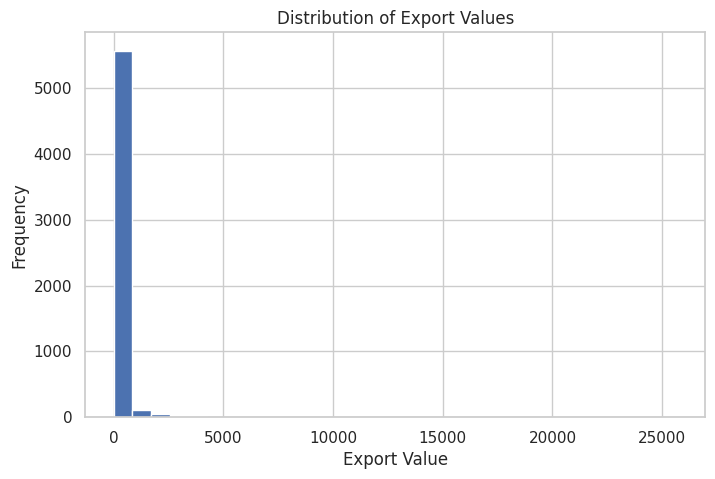

In [256]:
# ==========================================================
# 4.4 EXPORT VALUE DISTRIBUTION
# ==========================================================
#
# Objective:
# Understand the distribution of export values.
#
# This helps identify:
# • Skewness
# • Outliers
# • Extreme exporting markets
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(master["Export_Current"].dropna(), bins=30)

plt.title("Distribution of Export Values")

plt.xlabel("Export Value")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

The distribution is strongly right-skewed.
Most observations are concentrated at lower export values.
A small number of very large export values create a long right tail.
This is expected for international trade data, where a few country–commodity pairs account for a large share of exports.

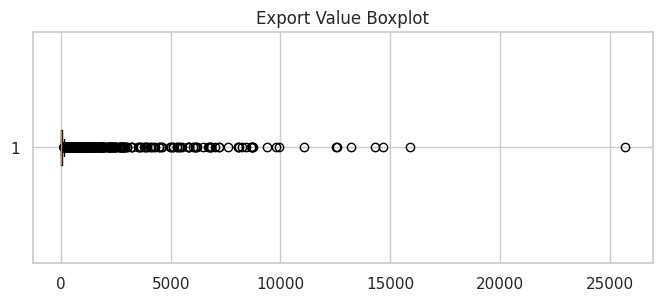

In [257]:
# ==============================================================================
# BOXPLOT
# ==============================================================================

plt.figure(figsize=(8,3))

plt.boxplot(
    master["Export_Current"].dropna(),
    vert=False
)

plt.title("Export Value Boxplot")

plt.show()

Outlier Detection and Treatment

The boxplot confirmed the presence of several extreme export values, which is expected in international trade datasets because a small number of country–commodity combinations account for a substantial proportion of total export value. These observations were reviewed and retained because they represent valid economic transactions rather than data-entry errors. However, infinite values generated during the calculation of Export_Growth_Rate (primarily when the previous export value was zero) were replaced with missing values to prevent distortion of subsequent statistical analyses. Given the strong right-skewness of export values, a logarithmic transformation will be considered during regression modelling to improve model stability and satisfy distributional assumptions.

In [258]:
# ==========================================================
# 4.5 TOP EXPORT DESTINATIONS
# ==========================================================
#
# Objective:
# Identify countries importing the largest value of
# Indian exports across all selected commodities.
# ==========================================================

top_countries = (

    master.groupby("Country")["Export_Current"]

    .sum()

    .sort_values(ascending=False)

    .head(20)

)

display(top_countries)

,Export_Current
Country,
U S A,226419.90
U Arab Emts,99841.05
Netherland,69827.78
Singapore,46740.49
Hong Kong,44092.31
U K,28773.40
Australia,27872.03
China P Rp,23648.21
South Africa,22704.61


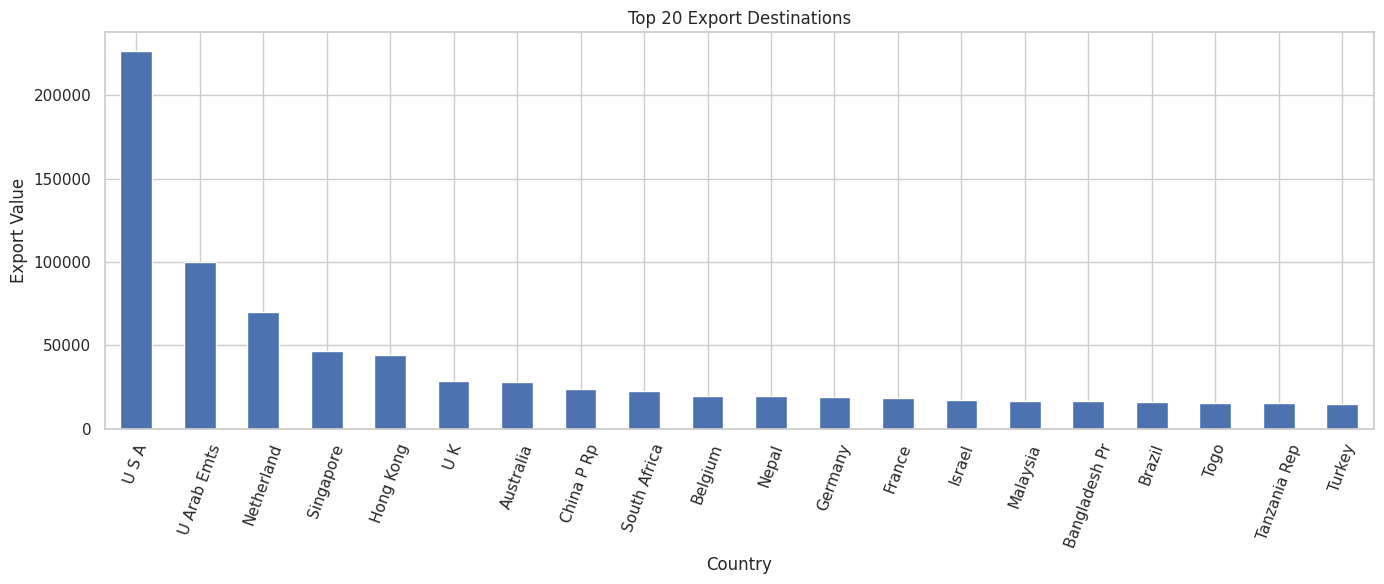

In [259]:
# ==========================================================
# VISUALIZATION:
# TOP 20 EXPORT DESTINATIONS
# ==========================================================

plt.figure(figsize=(14,6))

top_countries.plot(kind="bar")

plt.title("Top 20 Export Destinations")

plt.xlabel("Country")

plt.ylabel("Export Value")

plt.xticks(rotation=70)

plt.tight_layout()

plt.show()

In [260]:
# ==========================================================
# 4.6 COMMODITY-WISE EXPORT ANALYSIS
# ==========================================================
#
# Objective:
# Compare export values across the selected HS commodities.
# ==========================================================

commodity_export = (

    master.groupby("Commodity")["Export_Current"]

    .sum()

    .sort_values(ascending=False)

)

display(commodity_export)

,Export_Current
Commodity,
27,408239.25
85,195439.67
84,172002.63
71,164741.88
30,130399.15


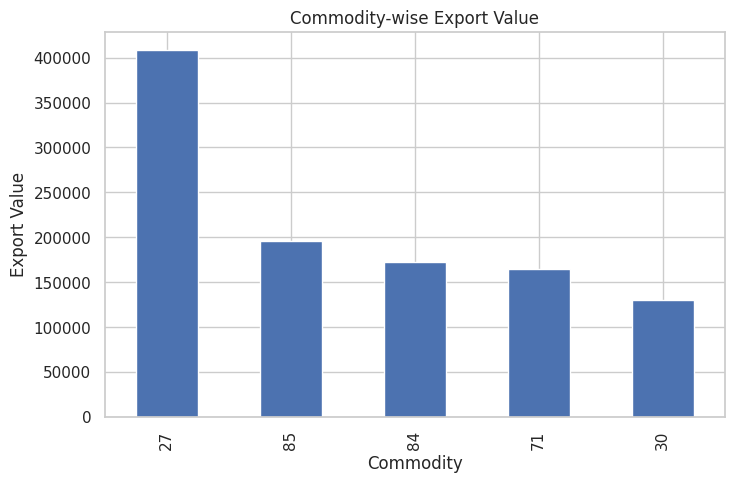

In [261]:
plt.figure(figsize=(8,5))

commodity_export.plot(kind="bar")

plt.title("Commodity-wise Export Value")

plt.xlabel("Commodity")

plt.ylabel("Export Value")

plt.grid(True)

plt.show()

In [262]:
# ==========================================================
# 4.7 EXPORT TREND ANALYSIS
# ==========================================================
#
# Objective:
# Examine how exports have changed over time.
#
# Helps answer Research Question 1.
# ==========================================================

yearly_export = (

    master.groupby("Year")["Export_Current"]

    .sum()

)

display(yearly_export)

,Export_Current
Year,
2021,105623.29
2022,173823.79
2023,215301.71
2024,207030.96
2025,197492.25
2026,171550.58


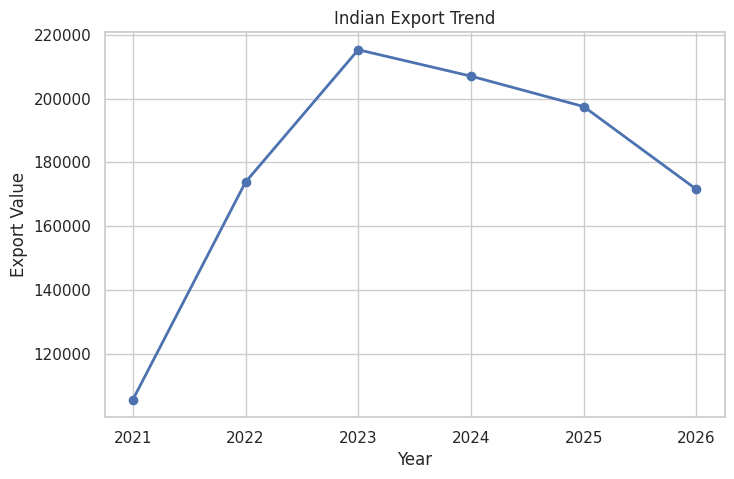

In [263]:
plt.figure(figsize=(8,5))

plt.plot(

    yearly_export.index,

    yearly_export.values,

    marker="o",

    linewidth=2

)

plt.title("Indian Export Trend")

plt.xlabel("Year")

plt.ylabel("Export Value")

plt.grid(True)

plt.show()

In [264]:
# ==============================================================================
# TOP IMPORTING COUNTRIES FOR EACH COMMODITY
# ==============================================================================

commodity_country = (

    master.groupby(["Commodity","Country"])

    ["Export_Current"]

    .sum()

    .reset_index()

)

display(commodity_country.head())

,Commodity,Country,Export_Current
0,27,Afghanistan,2.61
1,27,Albania,1347.88
2,27,Algeria,10.00
3,27,Angola,442.22
4,27,Antartica,0.30


In [265]:
# ==========================================================
# 4.8 CORRELATION ANALYSIS
# ==========================================================
#
# Objective:
# Identify relationships between exports and
# macroeconomic indicators.
#
# Variables considered:
# • GDP
# • GDP Growth
# • Population
# • Inflation
# • Trade
# ==========================================================

corr = master[[
    "Export_Current",
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Exports_GDP",
    "Imports_GDP",
    "Trade_GDP"
]].corr()

display(corr)

,Export_Current,GDP,GDP_Growth,GDP_Per_Capita,Population,Inflation,Exports_GDP,Imports_GDP,Trade_GDP
Export_Current,1.000000,0.263329,-0.039419,0.097846,0.198948,-0.041686,0.088869,0.041568,0.069577
GDP,0.263329,1.000000,-0.103103,0.216603,0.499748,-0.063056,-0.063503,-0.170265,-0.115598
GDP_Growth,-0.039419,-0.103103,1.000000,0.010233,-0.074215,-0.135838,0.123424,0.098318,0.115716
GDP_Per_Capita,0.097846,0.216603,0.010233,1.000000,-0.150847,-0.127295,0.526326,0.337071,0.454751
Population,0.198948,0.499748,-0.074215,-0.150847,1.000000,0.039021,-0.280226,-0.349980,-0.322207
Inflation,-0.041686,-0.063056,-0.135838,-0.127295,0.039021,1.000000,-0.158126,-0.123745,-0.146908
Exports_GDP,0.088869,-0.063503,0.123424,0.526326,-0.280226,-0.158126,1.000000,0.873196,0.973495
Imports_GDP,0.041568,-0.170265,0.098318,0.337071,-0.349980,-0.123745,0.873196,1.000000,0.961517
Trade_GDP,0.069577,-0.115598,0.115716,0.454751,-0.322207,-0.146908,0.973495,0.961517,1.000000


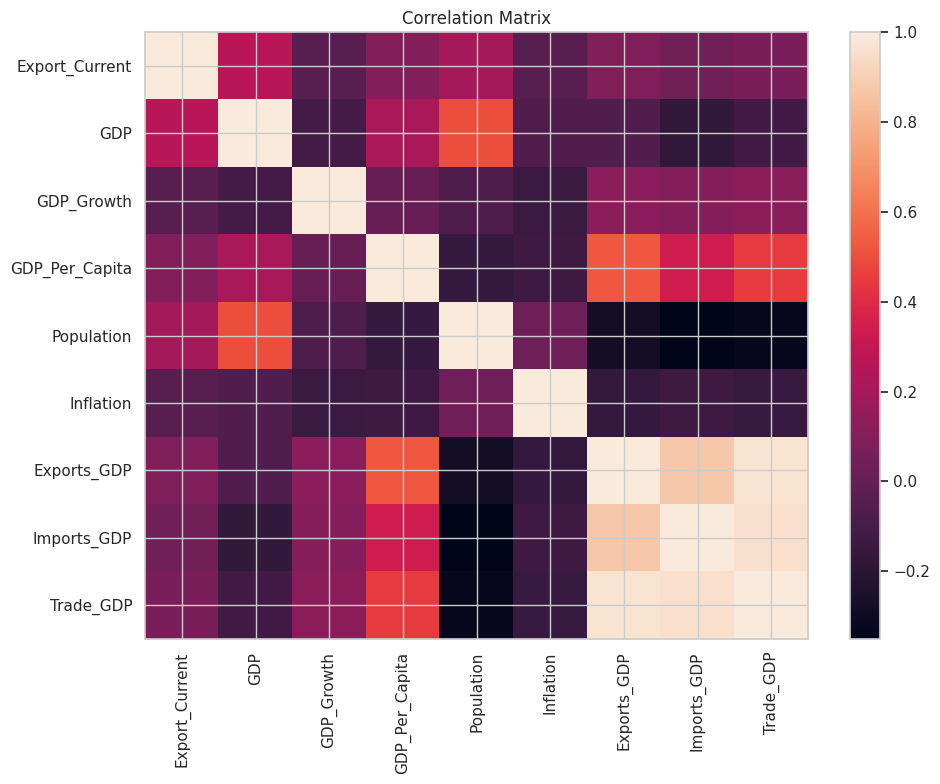

In [266]:
plt.figure(figsize=(10,8))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

The correlation matrix provides an initial indication of relationships among the predictor variables. However, correlation alone cannot determine whether multicollinearity will adversely affect regression modelling. Therefore, a Variance Inflation Factor (VIF) analysis was performed before model development.

In [267]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

features = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Exports_GDP",
    "Imports_GDP",
    "Trade_GDP"
]

# Keep only the selected predictors
X = master[features].copy()

# Replace infinite values, if any
X = X.replace([np.inf, -np.inf], np.nan)

# Use complete cases for VIF
X = X.dropna()

print("Rows used for VIF:", len(X))

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif = vif.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif)

Rows used for VIF: 2688


,Variable,VIF
0,Imports_GDP,inf
1,Trade_GDP,inf
2,Exports_GDP,inf
3,GDP,2.360441
4,GDP_Per_Capita,2.103650
5,Population,1.450331
6,Inflation,0.981574
7,GDP_Growth,0.922695


In [268]:
# Remove variables causing perfect multicollinearity
features_final = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

X_final = master[features_final].dropna()

### Multicollinearity Assessment

The correlation matrix indicated strong relationships among Exports_GDP,
Imports_GDP, and Trade_GDP. Variance Inflation Factor (VIF) was used to
quantify multicollinearity before model development.

In [269]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

features = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

# Keep only the selected predictors
X = master[features].copy()

# Replace infinite values, if any
X = X.replace([np.inf, -np.inf], np.nan)

# Use complete cases for VIF
X = X.dropna()

print("Rows used for VIF:", len(X))

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif = vif.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif)

Rows used for VIF: 2688


,Variable,VIF
0,Trade_GDP,3.184215
1,GDP,2.344426
2,GDP_Per_Capita,1.817895
3,Population,1.450098
4,Inflation,0.953883
5,GDP_Growth,0.921145


### Feature Selection Based on VIF

Exports_GDP, Imports_GDP, and Trade_GDP produced infinite VIF values,
indicating perfect linear dependence. Since Trade_GDP represents overall
trade openness, Trade_GDP was retained, while Exports_GDP and Imports_GDP
were excluded from the regression feature set.

In [270]:
import pandas as pd
import numpy as np
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

features_final = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Trade_GDP"
]

X_final = master[features_final].copy()
X_final = X_final.replace([np.inf, -np.inf], np.nan).dropna()

X_vif = add_constant(X_final)

vif_final = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Do not report the intercept VIF
vif_final = (
    vif_final[vif_final["Variable"] != "const"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("Rows used for final VIF:", len(X_final))
display(vif_final)

Rows used for final VIF: 2688


,Variable,VIF
0,GDP,1.929985
1,GDP_Per_Capita,1.817980
2,Population,1.668099
3,Trade_GDP,1.553709
4,GDP_Growth,1.063955
5,Inflation,1.058584


### Final Multicollinearity Result

After removing Exports_GDP and Imports_GDP, all retained predictor variables
had VIF values below 5. Therefore, no problematic multicollinearity remained,
and all six predictors were retained for subsequent modelling.

### Interpretation of Final VIF Results

The initial VIF assessment identified perfect multicollinearity among
Exports_GDP, Imports_GDP, and Trade_GDP. Because Trade_GDP represents total
trade openness and overlaps with its export and import components,
Exports_GDP and Imports_GDP were excluded from the final predictor set.

The revised VIF results ranged from 1.06 to 1.93, which is well below the
threshold of 5. This confirms that problematic multicollinearity was removed.
GDP, GDP_Growth, GDP_Per_Capita, Population, Inflation, and Trade_GDP were
therefore retained for regression modelling.

In [271]:
##need to apply this in cleansing
import numpy as np

# Replace infinity values with NaN
master["Export_Growth_Rate"] = master["Export_Growth_Rate"].replace(
    [np.inf, -np.inf],
    np.nan
)

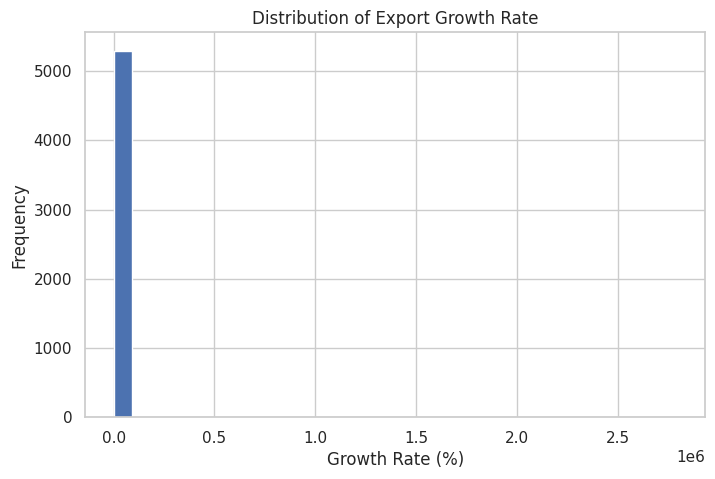

In [272]:
# ==========================================================
# 4.9 EXPORT GROWTH ANALYSIS
# ==========================================================
#
# Objective:
# Understand the distribution of export growth rates.
# ==========================================================

master["Export_Growth_Rate"].describe()
plt.figure(figsize=(8,5))

plt.hist(
    master["Export_Growth_Rate"].dropna(),
    bins=30
)

plt.title("Distribution of Export Growth Rate")

plt.xlabel("Growth Rate (%)")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ANALYSIS

In [307]:
# Common libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

from scipy.stats import kruskal
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Research Question 1

## Question
**Which Indian products and destination markets currently demonstrate the highest export demand, and how have these patterns evolved over time?**

## Hypotheses
- **H0₁:** Export-value distributions do not differ significantly across commodity groups.
- **H1₁:** At least one commodity group has a significantly different export-value distribution.

## Method
Destination-market ranking, commodity trend analysis, and a Kruskal–Wallis test.


In [308]:
# RQ1 data preparation

rq1 = master[["Country", "Commodity", "Year", "Export_Current"]].copy()
rq1 = rq1.replace([np.inf, -np.inf], np.nan)
rq1 = rq1.dropna(subset=["Country", "Commodity", "Year", "Export_Current"])
rq1 = rq1[rq1["Export_Current"] >= 0].copy()

print("RQ1 usable sample size:", len(rq1))


RQ1 usable sample size: 5806


,Country,Export_Current,Market_Share_Percent
0,U S A,226419.90,21.144483
1,U Arab Emts,99841.05,9.323771
2,Netherland,69827.78,6.520948
3,Singapore,46740.49,4.364914
4,Hong Kong,44092.31,4.117611
5,U K,28773.40,2.687037
6,Australia,27872.03,2.602862
7,China P Rp,23648.21,2.208415
8,South Africa,22704.61,2.120296
9,Belgium,19913.87,1.859680


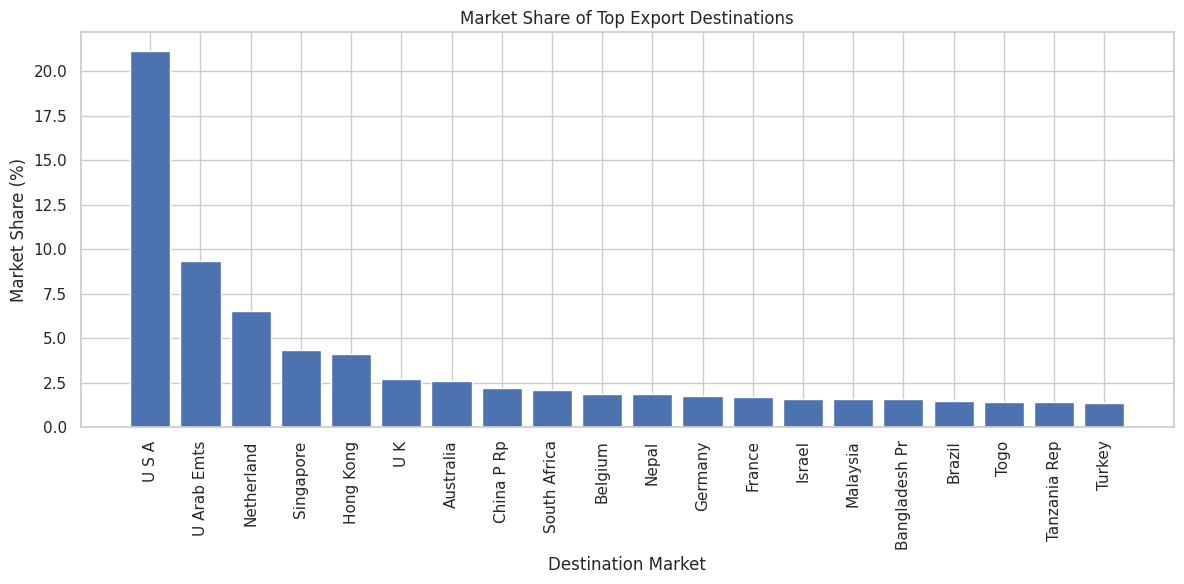

In [309]:
# RQ1 destination-market share

country_share = (
    rq1.groupby("Country", as_index=False)["Export_Current"]
       .sum()
)

country_share["Market_Share_Percent"] = (
    country_share["Export_Current"]
    / country_share["Export_Current"].sum()
    * 100
)

country_share = country_share.sort_values(
    "Market_Share_Percent", ascending=False
).reset_index(drop=True)

display(country_share.head(20))

plt.figure(figsize=(12, 6))
top20 = country_share.head(20)
plt.bar(top20["Country"], top20["Market_Share_Percent"])
plt.xticks(rotation=90)
plt.xlabel("Destination Market")
plt.ylabel("Market Share (%)")
plt.title("Market Share of Top Export Destinations")
plt.tight_layout()
plt.show()


,Year,Commodity,Export_Current
0,2021,27,26907.73
1,2021,30,19383.97
2,2021,71,26163.85
3,2021,84,18953.97
4,2021,85,14213.77


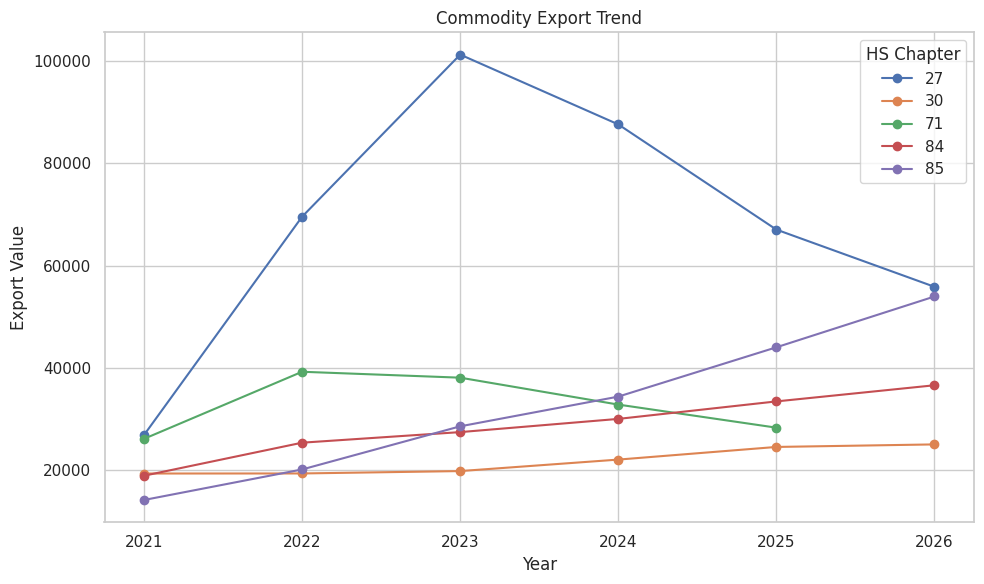

In [310]:
# RQ1 commodity trends

commodity_trend = (
    rq1.groupby(["Year", "Commodity"], as_index=False)["Export_Current"]
       .sum()
)

display(commodity_trend.head())

plt.figure(figsize=(10, 6))

for commodity, group in commodity_trend.groupby("Commodity"):
    group = group.sort_values("Year")
    plt.plot(group["Year"], group["Export_Current"], marker="o", label=str(commodity))

plt.xlabel("Year")
plt.ylabel("Export Value")
plt.title("Commodity Export Trend")
plt.legend(title="HS Chapter")
plt.tight_layout()
plt.show()


In [311]:
# RQ1 Kruskal-Wallis hypothesis test

commodity_groups = [
    group["Export_Current"].values
    for _, group in rq1.groupby("Commodity")
    if len(group) > 1
]

h_statistic, p_value = kruskal(*commodity_groups)

print("Kruskal-Wallis H statistic:", round(h_statistic, 4))
print("p-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0₁.")
    print("Conclusion: Export values differ significantly across commodity groups.")
else:
    print("Decision: Fail to reject H0₁.")


Kruskal-Wallis H statistic: 415.8915
p-value: 1.0240886935137692e-88
Decision: Reject H0₁.
Conclusion: Export values differ significantly across commodity groups.


# Research Question 2

## Question
**Which macroeconomic and trade-related factors significantly influence export demand across international markets?**

## Hypotheses
- **H0₂:** The selected macroeconomic indicators do not significantly influence export demand.
- **H1₂:** At least one selected macroeconomic indicator significantly influences export demand.

## Method
Correlation analysis, VIF-based feature selection, log transformation, and multiple linear regression with HC3 robust standard errors.


,Export_Current,GDP,GDP_Growth,GDP_Per_Capita,Population,Inflation,Exports_GDP,Imports_GDP,Trade_GDP
Export_Current,1.000000,0.263329,-0.039419,0.097846,0.198948,-0.041686,0.088869,0.041568,0.069577
GDP,0.263329,1.000000,-0.103103,0.216603,0.499748,-0.063056,-0.063503,-0.170265,-0.115598
GDP_Growth,-0.039419,-0.103103,1.000000,0.010233,-0.074215,-0.135838,0.123424,0.098318,0.115716
GDP_Per_Capita,0.097846,0.216603,0.010233,1.000000,-0.150847,-0.127295,0.526326,0.337071,0.454751
Population,0.198948,0.499748,-0.074215,-0.150847,1.000000,0.039021,-0.280226,-0.349980,-0.322207
Inflation,-0.041686,-0.063056,-0.135838,-0.127295,0.039021,1.000000,-0.158126,-0.123745,-0.146908
Exports_GDP,0.088869,-0.063503,0.123424,0.526326,-0.280226,-0.158126,1.000000,0.873196,0.973495
Imports_GDP,0.041568,-0.170265,0.098318,0.337071,-0.349980,-0.123745,0.873196,1.000000,0.961517
Trade_GDP,0.069577,-0.115598,0.115716,0.454751,-0.322207,-0.146908,0.973495,0.961517,1.000000


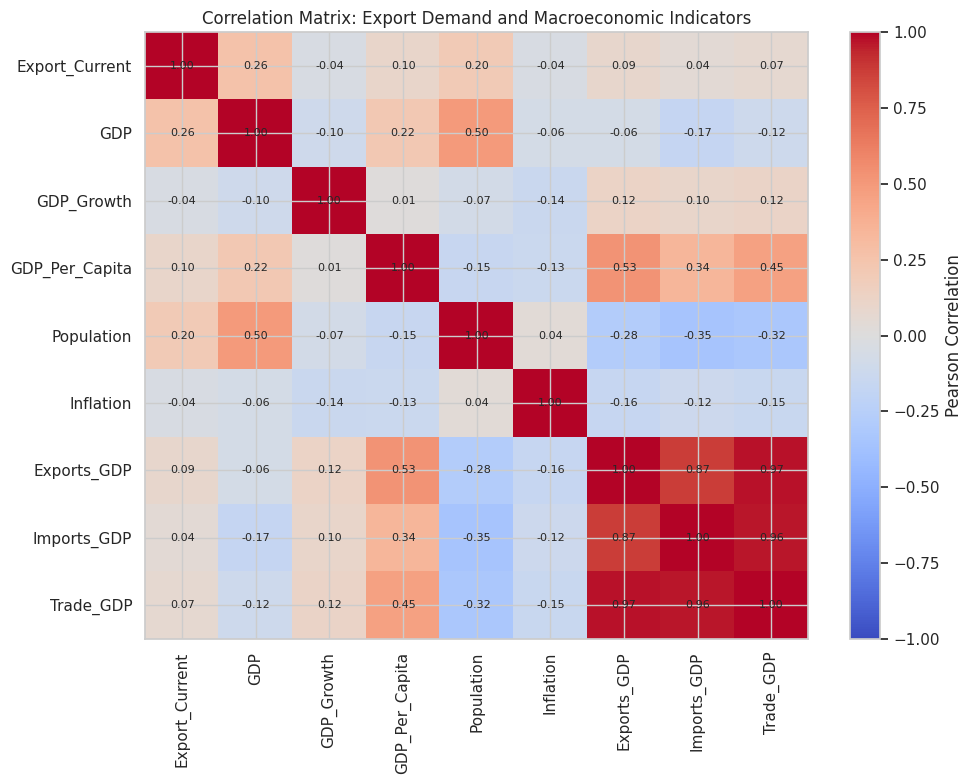

In [312]:
# RQ2 correlation analysis

rq2_corr_variables = [
    "Export_Current", "GDP", "GDP_Growth", "GDP_Per_Capita",
    "Population", "Inflation", "Exports_GDP", "Imports_GDP", "Trade_GDP"
]

corr = master[rq2_corr_variables].corr()
display(corr)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Pearson Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Matrix: Export Demand and Macroeconomic Indicators")
plt.tight_layout()
plt.show()


In [313]:
# RQ2 initial VIF

initial_features = [
    "GDP", "GDP_Growth", "GDP_Per_Capita", "Population",
    "Inflation", "Exports_GDP", "Imports_GDP", "Trade_GDP"
]

X_initial = master[initial_features].replace([np.inf, -np.inf], np.nan).dropna()
X_initial_vif = add_constant(X_initial)

initial_vif = pd.DataFrame({
    "Variable": X_initial_vif.columns,
    "VIF": [
        variance_inflation_factor(X_initial_vif.values, i)
        for i in range(X_initial_vif.shape[1])
    ]
})

initial_vif = initial_vif[
    initial_vif["Variable"] != "const"
].sort_values("VIF", ascending=False).reset_index(drop=True)

display(initial_vif)


,Variable,VIF
0,Imports_GDP,inf
1,Trade_GDP,inf
2,Exports_GDP,inf
3,GDP_Per_Capita,2.168161
4,GDP,1.935040
5,Population,1.713802
6,GDP_Growth,1.084378
7,Inflation,1.059242


In [314]:
# RQ2 final VIF after removing Exports_GDP and Imports_GDP

rq2_predictors = [
    "GDP", "GDP_Growth", "GDP_Per_Capita",
    "Population", "Inflation", "Trade_GDP"
]

X_final = master[rq2_predictors].replace([np.inf, -np.inf], np.nan).dropna()
X_final_vif = add_constant(X_final)

final_vif = pd.DataFrame({
    "Variable": X_final_vif.columns,
    "VIF": [
        variance_inflation_factor(X_final_vif.values, i)
        for i in range(X_final_vif.shape[1])
    ]
})

final_vif = final_vif[
    final_vif["Variable"] != "const"
].sort_values("VIF", ascending=False).reset_index(drop=True)

display(final_vif)


,Variable,VIF
0,GDP,1.929985
1,GDP_Per_Capita,1.817980
2,Population,1.668099
3,Trade_GDP,1.553709
4,GDP_Growth,1.063955
5,Inflation,1.058584


In [315]:
# RQ2 multiple linear regression

rq2 = master[["Export_Current"] + rq2_predictors].copy()
rq2 = rq2.replace([np.inf, -np.inf], np.nan).dropna()
rq2 = rq2[rq2["Export_Current"] >= 0].copy()
rq2["Log_Export_Current"] = np.log1p(rq2["Export_Current"])

X_raw = rq2[rq2_predictors]
X_standardised = (X_raw - X_raw.mean()) / X_raw.std()
X_model = sm.add_constant(X_standardised)
y = rq2["Log_Export_Current"]

rq2_model = sm.OLS(y, X_model).fit(cov_type="HC3")

print("RQ2 usable sample size:", len(rq2))
print(rq2_model.summary())


RQ2 usable sample size: 2651
                            OLS Regression Results                            
Dep. Variable:     Log_Export_Current   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     107.5
Date:                Tue, 04 Aug 2026   Prob (F-statistic):          1.66e-121
Time:                        12:51:29   Log-Likelihood:                -5366.6
No. Observations:                2651   AIC:                         1.075e+04
Df Residuals:                    2644   BIC:                         1.079e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const          

In [316]:
# RQ2 coefficient table and hypothesis decision

rq2_results = pd.DataFrame({
    "Coefficient": rq2_model.params,
    "Robust_Std_Error": rq2_model.bse,
    "Statistic": rq2_model.tvalues,
    "p_value": rq2_model.pvalues,
    "CI_Lower_95": rq2_model.conf_int()[0],
    "CI_Upper_95": rq2_model.conf_int()[1]
})

rq2_results["Significant_5pct"] = np.where(
    rq2_results["p_value"] < 0.05, "Yes", "No"
)

display(rq2_results.drop(index="const", errors="ignore").sort_values("p_value"))

print("R-squared:", round(rq2_model.rsquared, 4))
print("Adjusted R-squared:", round(rq2_model.rsquared_adj, 4))
print("Overall model p-value:", rq2_model.f_pvalue)

if rq2_model.f_pvalue < 0.05:
    print("Decision: Reject H0₂.")
else:
    print("Decision: Fail to reject H0₂.")


,Coefficient,Robust_Std_Error,Statistic,p_value,CI_Lower_95,CI_Upper_95,Significant_5pct
GDP,0.591777,0.058598,10.098989,5.581454e-24,0.476927,0.706626,Yes
Population,0.492125,0.052991,9.286995,1.587050e-20,0.388265,0.595986,Yes
GDP_Per_Capita,0.223880,0.051689,4.331291,1.482379e-05,0.122572,0.325189,Yes
GDP_Growth,-0.062688,0.032685,-1.917929,5.512002e-02,-0.126749,0.001374,No
Trade_GDP,0.033210,0.052369,0.634151,5.259822e-01,-0.069431,0.135851,No
Inflation,-0.000290,0.031747,-0.009142,9.927059e-01,-0.062513,0.061933,No


R-squared: 0.2332
Adjusted R-squared: 0.2315
Overall model p-value: 1.656160296246649e-121
Decision: Reject H0₂.


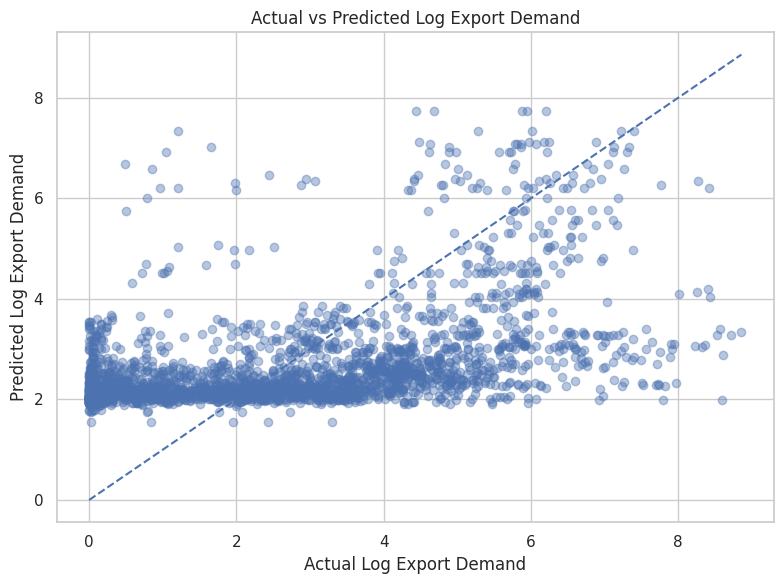

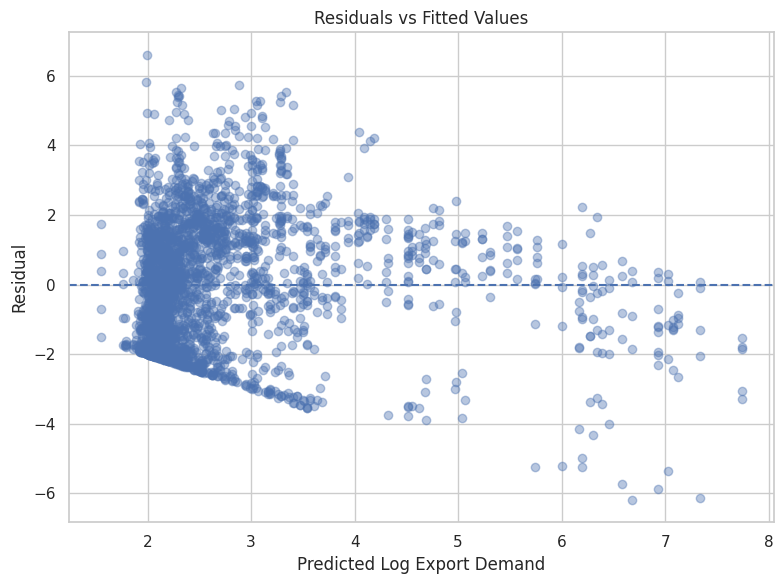

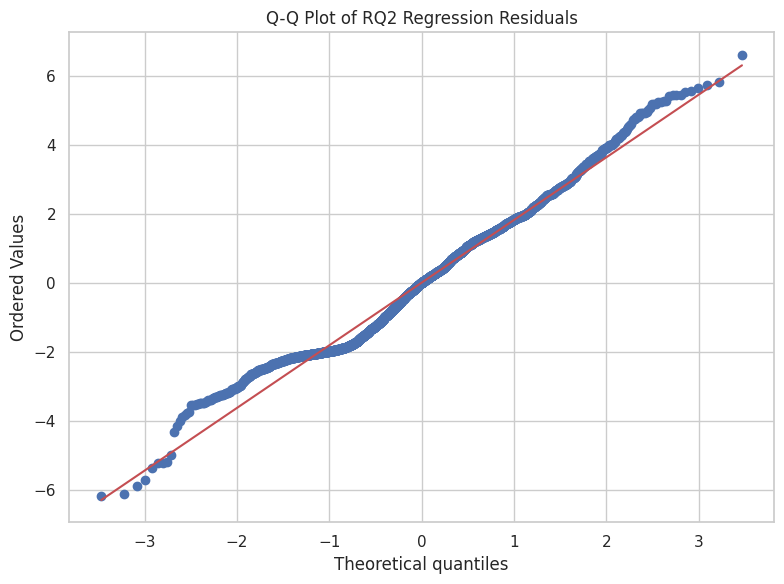

In [317]:
# RQ2 diagnostics

predicted = rq2_model.predict(X_model)
residuals = y - predicted

plt.figure(figsize=(8, 6))
plt.scatter(y, predicted, alpha=0.4)
minimum = min(y.min(), predicted.min())
maximum = max(y.max(), predicted.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual Log Export Demand")
plt.ylabel("Predicted Log Export Demand")
plt.title("Actual vs Predicted Log Export Demand")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(predicted, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Log Export Demand")
plt.ylabel("Residual")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of RQ2 Regression Residuals")
plt.tight_layout()
plt.show()


# Research Question 3

## Question
**How do supplier competition and India’s market share influence export opportunities across international markets?**

## Hypotheses
- **H0₃:** Supplier competition and India’s market share do not significantly influence export opportunities.
- **H1₃:** Supplier competition and/or India’s market share significantly influence export opportunities.

## Status
**Pending.** The current UN Comtrade extraction produced no usable India-specific supplier records. Run the template below after correcting the extraction.


In [318]:
# RQ3 template only: execute after correcting UN Comtrade extraction.

# Required outputs:
# - Destination_Import_Value
# - India_Market_Share
# - Supplier_Count
# - HHI
#
# Once available, merge them with the master dataset and estimate:
#
# rq3_model = sm.OLS(
#     export_opportunity_target,
#     sm.add_constant(rq3_predictors)
# ).fit(cov_type="HC3")
#
# Reject H0₃ when the overall model p-value is below 0.05.


RQ3 status: Pending correction of UN Comtrade extraction.


# Research Question 4

## Question
**Which international markets represent the most attractive export opportunities based on demand, market characteristics, and future growth potential?**

## Hypotheses
- **H0₄:** Machine-learning models do not improve predictive performance relative to the baseline linear regression model.
- **H1₄:** At least one machine-learning model improves predictive performance relative to the baseline linear regression model.

## Method
Out-of-time train/test split and comparison of Linear Regression, Random Forest, and XGBoost using MAE, RMSE, and R².


In [319]:
# RQ4 modelling dataset

rq4 = master.copy()
rq4 = rq4.replace([np.inf, -np.inf], np.nan)
rq4 = rq4[rq4["Year"] <= 2025].copy()
rq4 = rq4[
    rq4["Export_Current"].notna()
    & (rq4["Export_Current"] >= 0)
].copy()

numeric_features = [
    "Export_Previous", "GDP", "GDP_Growth", "GDP_Per_Capita",
    "Population", "Inflation", "Trade_GDP", "Year"
]

categorical_features = ["Country", "Commodity"]
rq4_features = numeric_features + categorical_features

X = rq4[rq4_features].copy()
y = np.log1p(rq4["Export_Current"])

train_mask = rq4["Year"] <= 2024
test_mask = rq4["Year"] == 2025

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("RQ4 total sample size:", len(rq4))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


RQ4 total sample size: 4985
Training rows: 3979
Testing rows: 1006


In [320]:
# RQ4 preprocessing

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot)
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])


In [321]:
# RQ4 evaluation function

def evaluate_model(model_name, model):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    pred_log = pipeline.predict(X_test)

    y_actual = np.expm1(y_test)
    y_pred = np.clip(np.expm1(pred_log), 0, None)

    result = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_actual, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_actual, y_pred)),
        "R2": r2_score(y_actual, y_pred)
    }

    return result, pipeline


In [322]:
# RQ4 models

linear_result, linear_pipeline = evaluate_model(
    "Linear Regression",
    LinearRegression()
)

rf_result, rf_pipeline = evaluate_model(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
)

try:
    from xgboost import XGBRegressor

    xgb_result, xgb_pipeline = evaluate_model(
        "XGBoost",
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )
except ImportError:
    xgb_result = None
    print("Install xgboost with: !pip install xgboost")


In [323]:
# RQ4 model comparison and hypothesis decision

results = [linear_result, rf_result]

if xgb_result is not None:
    results.append(xgb_result)

model_comparison = pd.DataFrame(results).sort_values(
    "RMSE", ascending=True
).reset_index(drop=True)

display(model_comparison)

baseline_rmse = model_comparison.loc[
    model_comparison["Model"] == "Linear Regression", "RMSE"
].iloc[0]

best_model = model_comparison.iloc[0]

if best_model["Model"] != "Linear Regression" and best_model["RMSE"] < baseline_rmse:
    print("Decision: Reject H0₄.")
else:
    print("Decision: Fail to reject H0₄.")


,Model,MAE,RMSE,R2
0,Random Forest,59.030886,291.456362,0.907508
1,XGBoost,65.113578,363.919348,0.855799
2,Linear Regression,19185.387811,579601.443722,-365776.358616


Decision: Reject H0₄.


,Feature,Importance
0,numeric__Export_Previous,0.961287
2,numeric__GDP_Growth,0.004302
1,numeric__GDP,0.003785
6,numeric__Trade_GDP,0.003775
4,numeric__Population,0.003731
7,numeric__Year,0.003359
245,categorical__Commodity_27,0.003096
3,numeric__GDP_Per_Capita,0.002970
5,numeric__Inflation,0.002805
149,categorical__Country_Morocco,0.000745


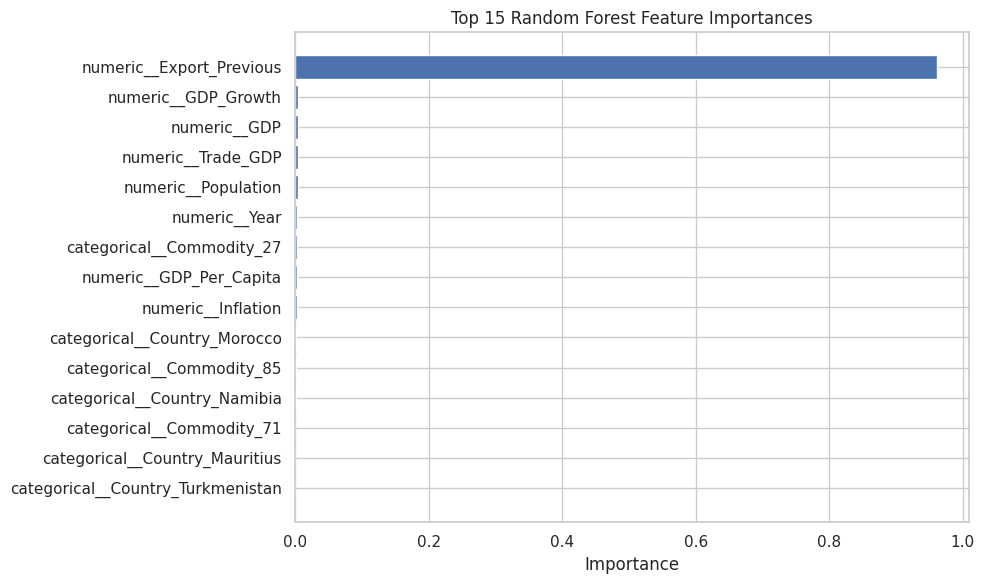

In [324]:
import pandas as pd
import matplotlib.pyplot as plt

# Get transformed feature names (if using a preprocessing pipeline)
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Feature importance from the Random Forest model
importances = rf_pipeline.named_steps["model"].feature_importances_

fi = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

# Display the top 15 features
display(fi.head(15))

plt.figure(figsize=(10, 6))
plt.barh(fi.head(15)["Feature"][::-1], fi.head(15)["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()